<div align="center">
<h1 style="color:red; font-weight:700;text-decoration:underline;"> ~ MINI PROJECT - 2 ~ </h1>
</div>

<div align="center">
<h1 style="color:purple; font-weight:700;text-decoration:underline;"> ~ MODULES - PYTHON LIBRARIES ~</h1>
</div>

<div align="center">
<h1 style="color:darkgreen; font-weight:700;text-decoration:underline; text-transform: uppercase"> ~ TOPIC - Student Performance and Attendance Analysis ~ </h1>
</div>

<div align="center">
<h3 style="color: black; font-weight:700;text-decoration:underline;"> ---- Data Preparation ---- </h3>
</div>

In [1]:
# ~~~ Importing Python Libraries ~~~
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)



In [29]:
# ~~~ 1. Loading of the student marks and attendance data ~~~ 

marks = pd.read_csv("Marks.csv")
marks


,Name,Mini Test 1,Mini Test 2,Live Test,Assignment
0,Arjun,9,5,14,16.0
1,Sophia Hardy,8,9,113,19.0
2,RAj,10,10,15,20.0
3,Emily,9,7,11,16.0
4,Ishaan Saini,8,7,14,11.0
...,...,...,...,...,...
105,Makayla,2,7,13,3.0
106,Ishaan Kapoor,9,6,13,20.0
107,Addison,8,8,12,12.0
108,Aditya Srivastava,5,5,8,17.0


In [30]:
attendance = pd.read_csv("Attendance.csv")
attendance


,Name,Attendance Day 1,Attendance Day 2,Attendance Day 3,Attendance Day 4,Attendance Day 5
0,Arjun,Y,N,N,N,Y
1,Sophia Hardy,Y,N,N,Y,Y
2,RAj,Y,Y,Y,Y,Y
3,Emily,Y,Y,N,Y,Y
4,Ishaan Saini,N,N,N,N,Y
...,...,...,...,...,...,...
105,Makayla,Y,Y,Y,Y,Y
106,Ishaan Kapoor,Y,N,N,Y,Y
107,Addison,Y,Y,Y,Y,Y
108,Aditya Srivastava,N,N,N,Y,Y


In [31]:
# ~~~ 2. Cleaning (space removal, unification of cases) of data ~~~ 
# i)
marks['Name'] = marks['Name'].str.strip().str.title()
marks


,Name,Mini Test 1,Mini Test 2,Live Test,Assignment
0,Arjun,9,5,14,16.0
1,Sophia Hardy,8,9,113,19.0
2,Raj,10,10,15,20.0
3,Emily,9,7,11,16.0
4,Ishaan Saini,8,7,14,11.0
...,...,...,...,...,...
105,Makayla,2,7,13,3.0
106,Ishaan Kapoor,9,6,13,20.0
107,Addison,8,8,12,12.0
108,Aditya Srivastava,5,5,8,17.0


In [32]:
# ii) 
attendance['Name'] = attendance['Name'].str.strip().str.title()

attendance

,Name,Attendance Day 1,Attendance Day 2,Attendance Day 3,Attendance Day 4,Attendance Day 5
0,Arjun,Y,N,N,N,Y
1,Sophia Hardy,Y,N,N,Y,Y
2,Raj,Y,Y,Y,Y,Y
3,Emily,Y,Y,N,Y,Y
4,Ishaan Saini,N,N,N,N,Y
...,...,...,...,...,...,...
105,Makayla,Y,Y,Y,Y,Y
106,Ishaan Kapoor,Y,N,N,Y,Y
107,Addison,Y,Y,Y,Y,Y
108,Aditya Srivastava,N,N,N,Y,Y


In [33]:
# ~~~ 3. Merging of the two DataFrames on the Name column ~~~ 

data = pd.merge(marks, attendance, on="Name", how="inner")
data

,Name,Mini Test 1,Mini Test 2,Live Test,Assignment,Attendance Day 1,Attendance Day 2,Attendance Day 3,Attendance Day 4,Attendance Day 5
0,Arjun,9,5,14,16.0,Y,N,N,N,Y
1,Sophia Hardy,8,9,113,19.0,Y,N,N,Y,Y
2,Raj,10,10,15,20.0,Y,Y,Y,Y,Y
3,Emily,9,7,11,16.0,Y,Y,N,Y,Y
4,Ishaan Saini,8,7,14,11.0,N,N,N,N,Y
...,...,...,...,...,...,...,...,...,...,...
105,Makayla,2,7,13,3.0,Y,Y,Y,Y,Y
106,Ishaan Kapoor,9,6,13,20.0,Y,N,N,Y,Y
107,Addison,8,8,12,12.0,Y,Y,Y,Y,Y
108,Aditya Srivastava,5,5,8,17.0,N,N,N,Y,Y


In [34]:
# ~~~ 4. Replacing of attendance values ('Y' or 'N') with numeric values (1 for 'Y' and 0 for 'N') ~~~

attendance_cols = [col for col in data.columns if "Attendance" in col]

for col in attendance_cols:
    data[col] = data[col].replace({'Y':1, 'N':0, 'y':1, 'n':0})

data

,Name,Mini Test 1,Mini Test 2,Live Test,Assignment,Attendance Day 1,Attendance Day 2,Attendance Day 3,Attendance Day 4,Attendance Day 5
0,Arjun,9,5,14,16.0,1,0,0,0,1
1,Sophia Hardy,8,9,113,19.0,1,0,0,1,1
2,Raj,10,10,15,20.0,1,1,1,1,1
3,Emily,9,7,11,16.0,1,1,0,1,1
4,Ishaan Saini,8,7,14,11.0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
105,Makayla,2,7,13,3.0,1,1,1,1,1
106,Ishaan Kapoor,9,6,13,20.0,1,0,0,1,1
107,Addison,8,8,12,12.0,1,1,1,1,1
108,Aditya Srivastava,5,5,8,17.0,0,0,0,1,1


In [35]:
# ~~~ 5. #  Missing marks is being filled with 0 ~~~

data.fillna(0, inplace=True)

data.isnull().sum()  # Verification


Name                0
Mini Test 1         0
Mini Test 2         0
Live Test           0
Assignment          0
Attendance Day 1    0
Attendance Day 2    0
Attendance Day 3    0
Attendance Day 4    0
Attendance Day 5    0
dtype: int64

<div align="center">
<h3 style="color: black; font-weight:700;text-decoration:underline;"> ---- Data Transformation ---- </h3>
</div>

In [36]:
# ~~~ 1. Creation of separate columns for below: ~~~

mark_cols = ["Mini Test 1", "Mini Test 2", "Live Test", "Assignment"]   
for col in mark_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0)    # Changing marks columns to numeric data type.

# i) Total marks
data["Total Marks"] = data[mark_cols].sum(axis=1)

# ii) Percentage marks (out of 100, assuming each test is out of 100)
data["Percentage Marks"] = data["Total Marks"] / (len(mark_cols)*100) * 100

# iii) Attendance percentage
data["Attendance %"] = data[attendance_cols].mean(axis=1) * 100

# iv) Weighted Percentage
data["Weighted %"] = (
    data["Attendance %"] * 0.40 +
    data["Mini Test 1"]  * 0.10 +
    data["Mini Test 2"]  * 0.10 +
    data["Live Test"]    * 0.20 +
    data["Assignment"]   * 0.20
)



In [37]:
# ~~~ 2. Classification of each student's performance into categories ~~~

def performance_category(p):
    if p >= 85:
        return "Excellent"
    elif p >= 71:
        return "Good"
    elif p >= 50:
        return "Average"
    else:
        return "Needs Improvement"

data["Category"] = data["Weighted %"].apply(performance_category)
data

,Name,Mini Test 1,Mini Test 2,Live Test,Assignment,Attendance Day 1,Attendance Day 2,Attendance Day 3,Attendance Day 4,Attendance Day 5,Total Marks,Percentage Marks,Attendance %,Weighted %,Category
0,Arjun,9.0,5.0,14.0,16.0,1,0,0,0,1,44.0,11.00,40.0,23.4,Needs Improvement
1,Sophia Hardy,8.0,9.0,113.0,19.0,1,0,0,1,1,149.0,37.25,60.0,52.1,Average
2,Raj,10.0,10.0,15.0,20.0,1,1,1,1,1,55.0,13.75,100.0,49.0,Needs Improvement
3,Emily,9.0,7.0,11.0,16.0,1,1,0,1,1,43.0,10.75,80.0,39.0,Needs Improvement
4,Ishaan Saini,8.0,7.0,14.0,11.0,0,0,0,0,1,40.0,10.00,20.0,14.5,Needs Improvement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,Makayla,2.0,7.0,13.0,3.0,1,1,1,1,1,25.0,6.25,100.0,44.1,Needs Improvement
106,Ishaan Kapoor,9.0,6.0,13.0,20.0,1,0,0,1,1,48.0,12.00,60.0,32.1,Needs Improvement
107,Addison,8.0,8.0,12.0,12.0,1,1,1,1,1,40.0,10.00,100.0,46.4,Needs Improvement
108,Aditya Srivastava,5.0,5.0,8.0,17.0,0,0,0,1,1,35.0,8.75,40.0,22.0,Needs Improvement


<div align="center">
<h3 style="color: black; font-weight:700;text-decoration:underline;"> ---- Analysis ---- </h3>
</div>

In [38]:
# ~~~ 1. Students with attendance below 75% but weighted percentage >50%  ~~~

low_attendance_high_score = data[(data["Attendance %"] < 75) & (data["Weighted %"] > 50)]
low_attendance_high_score


,Name,Mini Test 1,Mini Test 2,Live Test,Assignment,Attendance Day 1,Attendance Day 2,Attendance Day 3,Attendance Day 4,Attendance Day 5,Total Marks,Percentage Marks,Attendance %,Weighted %,Category
1,Sophia Hardy,8.0,9.0,113.0,19.0,1,0,0,1,1,149.0,37.25,60.0,52.1,Average


In [39]:
# ~~~ 2. Top three students based on percentage marks ~~~

top3 = data.sort_values(by="Percentage Marks", ascending=False).head(3)
top3


,Name,Mini Test 1,Mini Test 2,Live Test,Assignment,Attendance Day 1,Attendance Day 2,Attendance Day 3,Attendance Day 4,Attendance Day 5,Total Marks,Percentage Marks,Attendance %,Weighted %,Category
1,Sophia Hardy,8.0,9.0,113.0,19.0,1,0,0,1,1,149.0,37.25,60.0,52.1,Average
2,Raj,10.0,10.0,15.0,20.0,1,1,1,1,1,55.0,13.75,100.0,49.0,Needs Improvement
6,Maya,10.0,10.0,15.0,20.0,0,0,0,1,1,55.0,13.75,40.0,25.0,Needs Improvement


In [40]:
# ~~~ 3. Impact of attendance on Tests/Assignment marks ~~~

print(data[["Attendance %", "Weighted %"]].corr())


              Attendance %  Weighted %
Attendance %      1.000000    0.962213
Weighted %        0.962213    1.000000


<div align="center">
<h3 style="color: black; font-weight:700;text-decoration:underline;"> ---- Visualization ---- </h3>
</div>

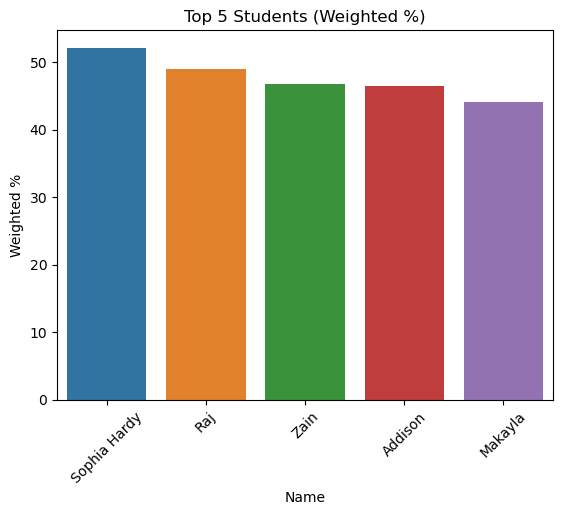

In [41]:
# ~~~ 1. A bar chart displaying weighted percentages for top 5 students ~~~

top5 = data.sort_values(by="Weighted %", ascending=False).head(5)
sns.barplot(x="Name", y="Weighted %", data=top5, hue="Name")
plt.title("Top 5 Students (Weighted %)")
plt.xticks(rotation=45)
plt.show()


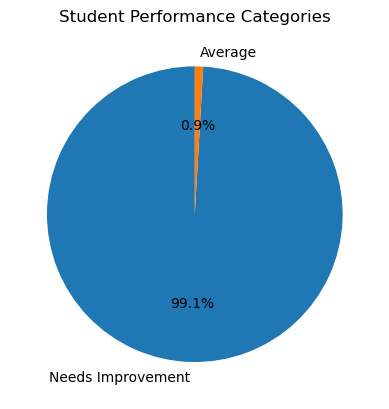

In [42]:
# ~~~ 2. A pie chart showing the distribution of students across the four performance categories ~~~

data["Category"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90)
plt.title("Student Performance Categories")
plt.ylabel("")
plt.show()


In [ ]:
# ~~~ 3. Box plots for each test (Live Test, Mini Test 1, Mini Test 2, Assignment) to visualize the spread and detect potential outliers in scores ~~~

sns.boxplot(data=data[mark_cols])
plt.title("Spread of Marks in Tests")
plt.show()


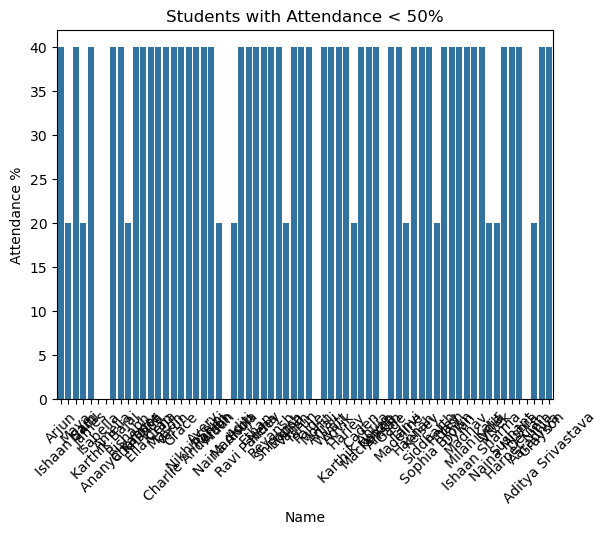

In [43]:
# ~~~ 4. A chart to show the students where attendance is less than 50% ~~~

low_att = data[data["Attendance %"] < 50]
sns.barplot(x="Name", y="Attendance %", data=low_att)
plt.title("Students with Attendance < 50%")
plt.xticks(rotation=45)
plt.show()


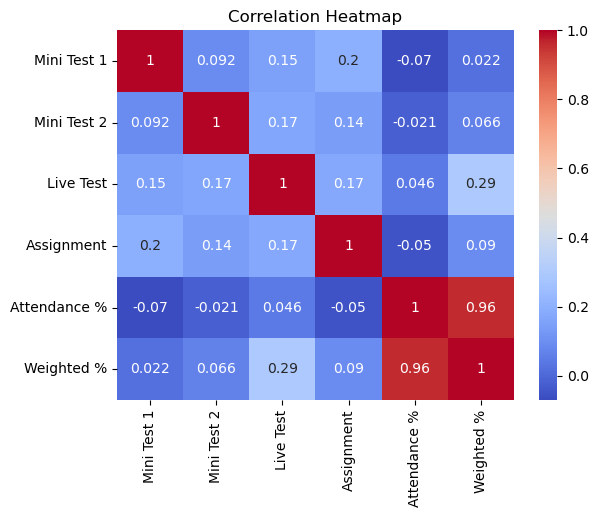

In [44]:
# ~~~ 5. Any other visualization/analysis inferred from data for the management ~~~

sns.heatmap(data[["Mini Test 1", "Mini Test 2", "Live Test", "Assignment", "Attendance %", "Weighted %"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

